In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set style
sns.set_theme(style='whitegrid')
plt.rcParams['font.size'] = 11
os.makedirs('visualizations', exist_ok=True)

# Load data
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print(f'Total records: {df.shape[0]}, Total attributes: {df.shape[1]}')

# Impute missing values with group medians (Season & Crop)
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
  df[col] = df.groupby(['Season', 'Crop'])[col].transform(
      lambda x: x.fillna(x.median())
  )

print('Null values remaining:', df.isnull().sum().sum())

Total records: 4000, Total attributes: 28
Null values remaining: 0


In [2]:
seasonal_stats = (
    df.groupby('Season')
    .agg(
        Farm_Count=('Farm_ID', 'count'),
        Avg_Rainfall_mm=('Rainfall_mm', 'mean'),
        Avg_Temp_C=('Avg_Temperature_C', 'mean'),
        Avg_Yield_t_ha=('Yield_Tonnes_Ha', 'mean'),
        Avg_Water_Used_m3=('Water_Used_m3', 'mean'),
        Avg_Net_Profit_INR=('Profit_INR', 'mean'),
        Avg_Pest_Risk_pct=('Disease_Pest_Risk_pct', 'mean'),
    )
    .round(2)
)

seasonal_stats

,Farm_Count,Avg_Rainfall_mm,Avg_Temp_C,Avg_Yield_t_ha,Avg_Water_Used_m3,Avg_Net_Profit_INR,Avg_Pest_Risk_pct
Season,,,,,,,
Kharif,1779,852.10,28.45,5.63,6102.20,178914.65,54.47
Rabi,1627,435.95,23.49,5.09,5846.99,87689.47,40.48
Zaid,594,299.16,31.04,4.64,6419.89,-24804.82,38.22


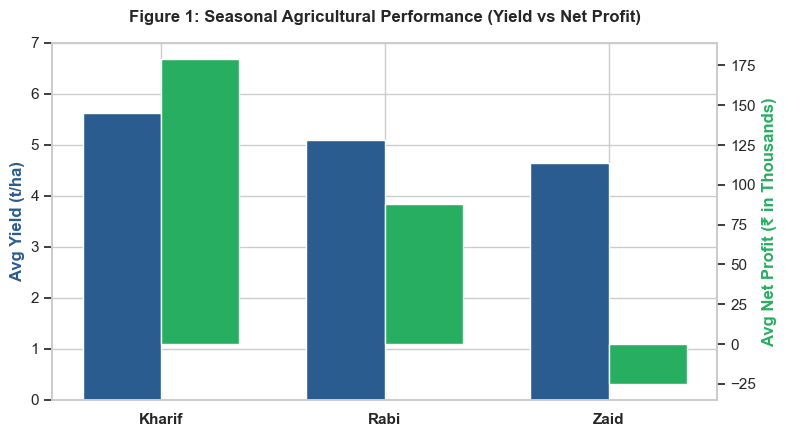

In [3]:
fig, ax1 = plt.subplots(figsize=(8, 4.5))
seasons = ['Kharif', 'Rabi', 'Zaid']
yield_means = [df[df['Season'] == s]['Yield_Tonnes_Ha'].mean() for s in seasons]
profit_means = [
    df[df['Season'] == s]['Profit_INR'].mean() / 1000 for s in seasons
]

x = np.arange(len(seasons))
width = 0.35

ax1.bar(
    x - width / 2, yield_means, width, label='Avg Yield (t/ha)', color='#2b5c8f'
)
ax1.set_ylabel('Avg Yield (t/ha)', color='#2b5c8f', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(seasons, fontweight='bold')
ax1.set_ylim(0, 7)

ax2 = ax1.twinx()
ax2.bar(
    x + width / 2,
    profit_means,
    width,
    label='Avg Net Profit (₹ k)',
    color='#27ae60',
)
ax2.set_ylabel(
    'Avg Net Profit (₹ in Thousands)', color='#27ae60', fontweight='bold'
)
ax2.grid(False)

plt.title(
    'Figure 1: Seasonal Agricultural Performance (Yield vs Net Profit)',
    fontweight='bold',
    pad=15,
)
plt.tight_layout()
plt.savefig('visualizations/fig1_yield_profit.png', dpi=300)
plt.show()

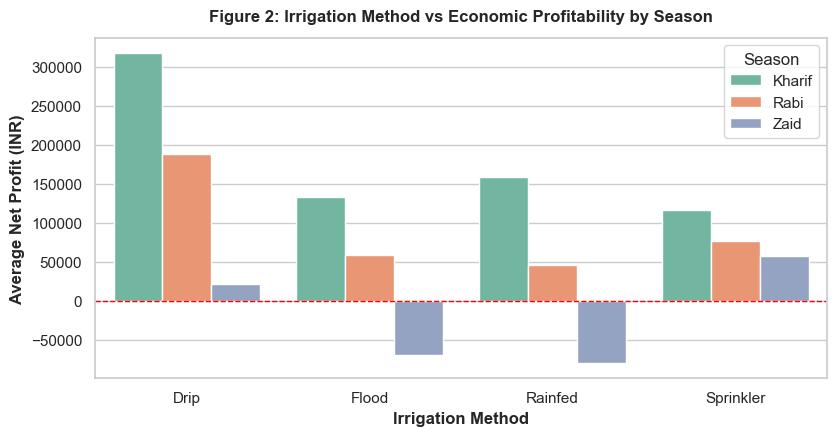

In [4]:
plt.figure(figsize=(8.5, 4.5))
sns.barplot(
    data=df,
    x='Irrigation_Method',
    y='Profit_INR',
    hue='Season',
    palette='Set2',
    errorbar=None,
)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title(
    'Figure 2: Irrigation Method vs Economic Profitability by Season',
    fontweight='bold',
    pad=12,
)
plt.xlabel('Irrigation Method', fontweight='bold')
plt.ylabel('Average Net Profit (INR)', fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/fig2_irrigation_profit.png', dpi=300)
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_5840\3677818898.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=df, x='Season', y='Rainfall_mm', palette='Blues')
C:\Users\Admin\AppData\Local\Temp\ipykernel_5840\3677818898.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Admin\AppData\Local\Temp\ipykernel_5840\3677818898.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


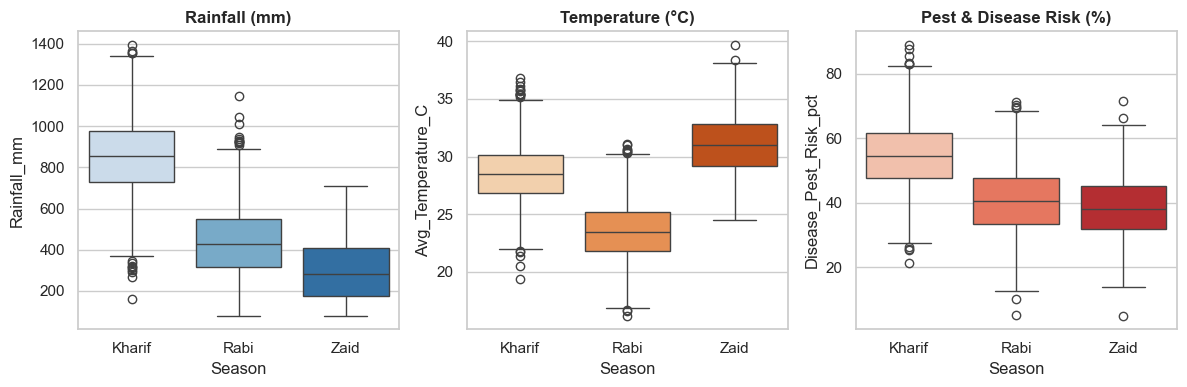

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
sns.boxplot(ax=axes[0], data=df, x='Season', y='Rainfall_mm', palette='Blues')
axes[0].set_title('Rainfall (mm)', fontweight='bold')

sns.boxplot(
    ax=axes[1], data=df, x='Season', y='Avg_Temperature_C', palette='Oranges'
)
axes[1].set_title('Temperature (°C)', fontweight='bold')

sns.boxplot(
    ax=axes[2], data=df, x='Season', y='Disease_Pest_Risk_pct', palette='Reds'
)
axes[2].set_title('Pest & Disease Risk (%)', fontweight='bold')

plt.tight_layout()
plt.savefig('visualizations/fig3_environmental_factors.png', dpi=300)
plt.show()

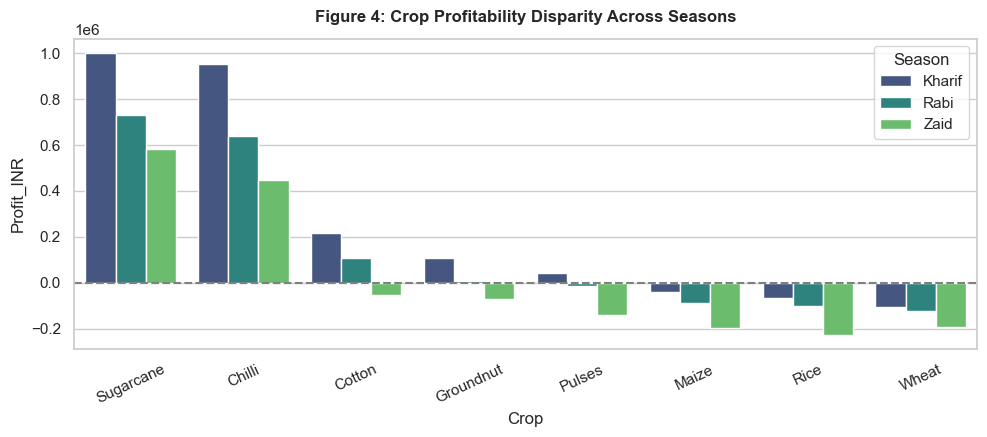

In [7]:
plt.figure(figsize=(10, 4.5))
crop_order = (
    df.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False).index
)
sns.barplot(
    data=df,
    x='Crop',
    y='Profit_INR',
    hue='Season',
    order=crop_order,
    palette='viridis',
    errorbar=None,
)
plt.axhline(0, color='gray', linestyle='--')
plt.title(
    'Figure 4: Crop Profitability Disparity Across Seasons',
    fontweight='bold',
    pad=12,
)
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig('visualizations/fig4_crop_profit.png', dpi=300)
plt.show()